In [3]:
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np


from easydynamics.utils import detailed_balance_factor


Text(0.5, 1.0, 'Detailed balance factor for different temperatures, normalized to 1 at zero energy transfer')

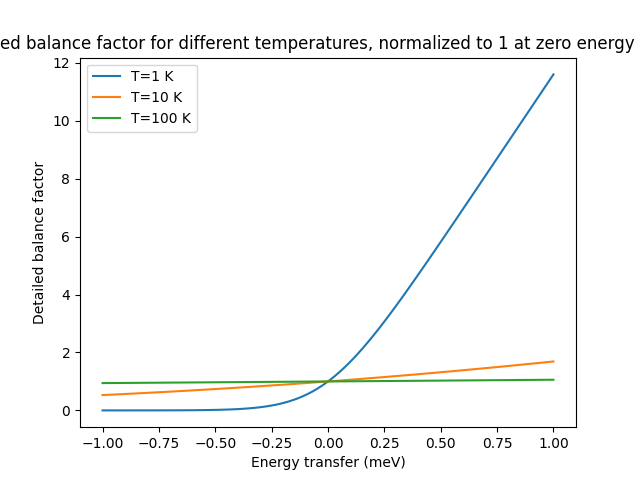

In [4]:

temperatures=[1, 10, 100]
temperature_unit='K'
omega=np.linspace(-1,1,100)
# omega=1.0
omega_unit='meV'

plt.figure()
for temperature in temperatures:
    DBF = detailed_balance_factor(omega, temperature, omega_unit,temperature_unit)
    plt.plot(omega, DBF, label=f'T={temperature} K')
plt.legend()
plt.xlabel('Energy transfer (meV)')
plt.ylabel('Detailed balance factor')
plt.title('Detailed balance factor for different temperatures, normalized to 1 at zero energy transfer')

Text(0.5, 1.0, 'Detailed balance factor for different temperatures, not normalized')

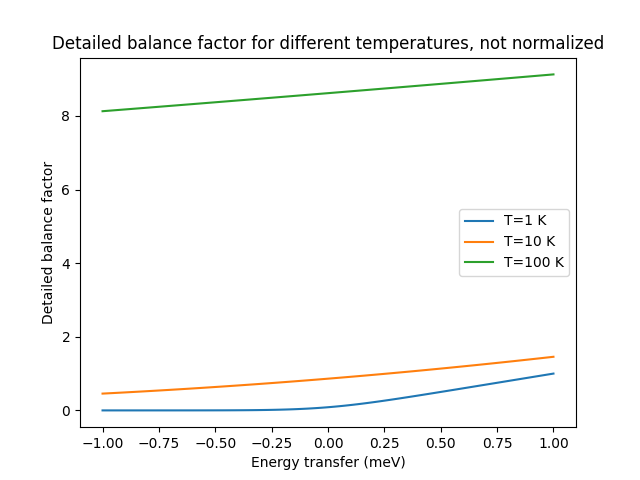

In [5]:

temperatures=[1, 10, 100]
temperature_unit='K'
omega=np.linspace(-1,1,100)
# omega=1.0
omega_unit='meV'

plt.figure()
for temperature in temperatures:
    DBF = detailed_balance_factor(omega, temperature, omega_unit,temperature_unit,divide_by_temperature=False)
    plt.plot(omega, DBF, label=f'T={temperature} K')
plt.legend()
plt.xlabel('Energy transfer (meV)')
plt.ylabel('Detailed balance factor')
plt.title('Detailed balance factor for different temperatures, not normalized')

C:\Users\henrikjacobsen3\AppData\Local\Temp\ipykernel_30208\4138583467.py:4: RuntimeWarning: invalid value encountered in divide
  y = x / (1 - np.exp(-x))


Text(0.5, 1.0, 'Comparison of exact and approximate expressions for large x')

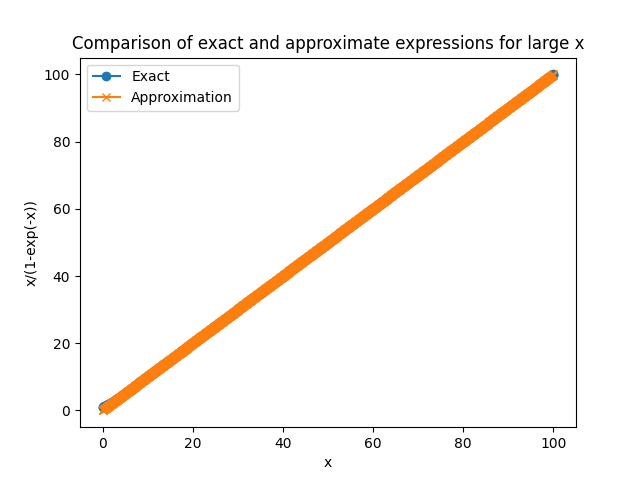

In [17]:
import numpy as np
x= np.linspace(0,100,1000)

y = x / (1 - np.exp(-x))

y_approx = x

plt.figure()
plt.plot(x,y,marker='o')
plt.plot(x,y_approx,marker='x')
plt.xlabel('x')
plt.ylabel('x/(1-exp(-x))')
plt.legend(['Exact','Approximation'])
plt.title('Comparison of exact and approximate expressions for large x')

In [ ]:
import numpy as np
x= np.linspace(0,0.1,1000)

y = x / (1 - np.exp(-x))

y_approx = 1 + x/2 + x**2/12

plt.figure()
plt.plot(x,y,marker='o')
plt.plot(x,y_approx,marker='x')
plt.xlabel('x')
plt.ylabel('x/(1-exp(-x))')
plt.legend(['Exact','Approximation'])
plt.title('Comparison of exact and approximate expressions for small x')

In [21]:
from scipp.constants import Boltzmann as kB
import scipp as sc
a = sc.to_unit(kB, 'meV/K')
a

<scipp.Variable> ()    float64          [meV/K]  0.0861733

In [22]:
def _convert_to_scipp_variable(value, unit: str, name: str = "value") -> sc.Variable:
    """Convert various input types to a scipp Variable with proper units."""
    if isinstance(value, sc.Variable):
        return value
    
    # Convert to numpy array first for consistent handling
    if isinstance(value, (int, float)):
        array_value = np.array(value)
    elif isinstance(value, (list, tuple)):
        array_value = np.array(value)
    elif isinstance(value, np.ndarray):
        array_value = value
    else:
        raise TypeError(f"{name} must be a number, list, numpy array, or scipp Variable")
    
    # Create appropriate scipp variable based on shape
    if array_value.shape == () or (array_value.shape == (1,)):
        # Scalar or single-element array
        return sc.scalar(value=float(array_value.flat[0]), unit=unit)
    else:
        # Multi-element array
        return sc.array(dims=['x'], values=array_value, unit=unit)
    

a=_convert_to_scipp_variable(100,unit='meV',name='value')
a

<scipp.Variable> ()    float64            [meV]  100